In [1]:
import sys, os
print(sys.version)
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("error", category=RuntimeWarning)

3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]


In [68]:
train = pd.read_csv(os.path.join("data", "sign_mnist_train.csv"))
print(train.shape)
train.head()

(27455, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [69]:
y_col = "label"
X = (
    train
    .drop(y_col, axis=1)
    .to_numpy()
    .astype(np.int16) # Downcast to save memory 
)
y = train[y_col].to_numpy().astype(np.int8)
possible_labels = np.unique(y)
Y = y[:, np.newaxis] == possible_labels[np.newaxis]
print(X.shape, Y.shape)
del train

(27455, 784) (27455, 24)


In [76]:
subset = y <= 2
X_ = X[subset]
Y_ = Y[subset, :3]
poss_labels = [0, 1, 2]
print(X_.shape, Y_.shape)

(3280, 784) (3280, 3)


C:\Users\archi\AppData\Local\Temp\ipykernel_10824\1939488016.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  samples = np.array([


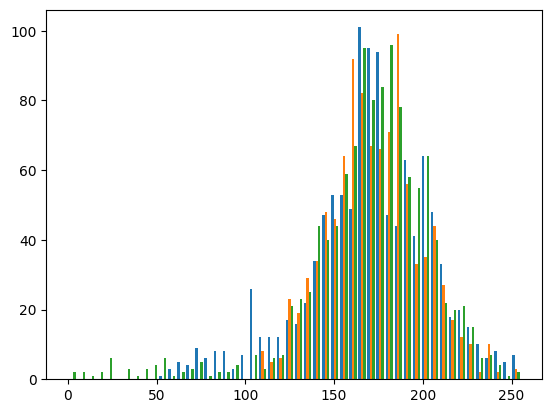

In [71]:
samples = np.array([
    X_[y[subset]==label, 250]
    for label in [0, 1, 2]
])
plt.hist(samples.T, bins=50)
plt.show()

In [135]:
def entropy(freqs, eps=1e-10):
    _sums = np.sum(freqs, axis=-1, keepdims=True)
    p = np.array(freqs) / np.maximum(_sums, eps)
    return -1. * np.sum(
        p * np.log2(np.maximum(p, eps)),
        axis = -1
    )

def conditional_entropy(freqs):
    shares = np.sum(freqs, axis=-1, keepdims=True)
    _sums = np.sum(
        shares, 
        axis = -min(2, np.ndim(shares)),
        keepdims=True
    )
    shares = shares / _sums
    entropies = entropy(freqs)
    if np.ndim(shares) > 2:
        cond_entr = [
            entr.dot(s)
            for entr, s in zip(entropies, shares)
        ]
    else:
        cond_entr = np.dot(entropies, shares)
    return np.squeeze(cond_entr)

In [136]:
a = [20, 10]
b = [10, 0]
c = [15, 7]
d = [15, 3]
print(entropy(a))
print(entropy(b))
print(entropy([a, b]))
print(entropy([
    [a, b],
    [c, d]
]))

print(conditional_entropy([a, b]))
print(conditional_entropy([c, d]))
print(conditional_entropy([
    [a, b],
    [c, d],
    [a, b],
    [c, d]
]))

0.9182958340544896
-0.0
[ 0.91829583 -0.        ]
[[ 0.91829583 -0.        ]
 [ 0.90239328  0.65002242]]
0.6887218755408672
0.7888263952789978
[0.68872188 0.7888264  0.68872188 0.7888264 ]


## Decision tree implementation

In [72]:
SPLITS_TO_TEST = np.arange(X.min().min(), X.max().max()) + 0.5
SPLITS_TO_TEST[[0, -1]]

array([  0.5, 254.5])

In [134]:
class TreeClassifier():

    def __init__(self, 
                 classes: np.ndarray,
                 max_depth: int = 1,
                 min_samples_per_leaf: int = 1):
        self.classes = classes
        self.max_depth = max_depth
        self.min_samples_per_leaf = min_samples_per_leaf

    def get_split_result(self, x_vec, boundary, y_matrix):
        test = x_vec <= boundary
        return np.array([
            y_matrix[test].sum(0),
            y_matrix[~test].sum(0)
        ])
        
    def single_feature_best_split(self, 
                                  x_vec, 
                                  y_matrix,
                                  splits = SPLITS_TO_TEST,
                                  return_entropies: bool = False):
        _splits = np.array([
            self.get_split_result(x_vec, s, y_matrix)
            for s in splits
        ])
        conditional_entropies = conditional_entropy(_splits)
        argmin = np.argmin(conditional_entropies)
        best = splits[argmin]
        if return_entropies:
            return argmin, best, conditional_entropies
        else:
            return argmin, best
        
    def all_features_best_split(self, 
                                X, 
                                y_matrix,
                                splits = SPLITS_TO_TEST,
                                return_entropies: bool = False):
        d = X.shape[1]
        argmins = np.inf * np.ones(d)
        entropies = -1. * np.ones((d, len(splits)))
        for i in range(d):
            argmins[i], _, entropies[i] = self.single_feature_best_split(
                x_vec = X[:, i],
                y_matrix = y_matrix,
                splits = splits,
                return_entropies = True
            )
        argmins = argmins.astype(int)
        min_entropies = entropies[np.arange(d), argmins]
        feature_to_use = np.argmin(min_entropies)
        boundary_to_use = splits[argmins[feature_to_use]]
        if return_entropies:
            return feature_to_use, boundary_to_use, entropies
        else:
            return feature_to_use, boundary_to_use

    def fit(self, X, y_matrix, **kwargs):
        self.branches = None
        self.frequencies = y_matrix.sum(0)
        if self.max_depth > 0:
            n = X.shape[0]
            if n > (threshold := self.min_samples_per_leaf):
                self.feature, self.boundary = self.all_features_best_split(
                    X = X,
                    y_matrix = y_matrix,
                    **kwargs
                )
                test = X[:, self.feature] <= self.boundary
                sufficient = lambda arr: arr.sum() >= threshold
                if sufficient(test) and sufficient(~test):
                    self.branches = []
                    for subset in [~test, test]:
                        branch = TreeClassifier(
                            classes = self.classes,
                            max_depth = self.max_depth - 1,
                            min_samples_per_leaf = self.min_samples_per_leaf
                        )
                        branch.fit(X[subset], y_matrix[subset], **kwargs)
                        self.branches.append(branch)

    def predict_proba(self, X, **kwargs):
        if np.ndim(X) == 1:
            X = X[np.newaxis] # Enforce row-vector format
        n = X.shape[0]
        if self.branches is None:
            freqs = self.frequencies / self.frequencies.sum()
            probs = np.array([freqs for _ in range(n)])
        else:
            probs = -1. * np.ones((n, len(self.classes)))
            above_threshold = X[:, self.feature] <= self.boundary
            for case, branch in enumerate(self.branches):
                select = above_threshold == case
                probs[select] = branch.predict_proba(X[select], **kwargs)
            assert np.all(probs >= 0), f"predict_proba failed!"
        return probs
    
    def predict(self, X, **kwargs):
        probs = self.predict_proba(X, **kwargs)
        return self.classes[np.argmax(probs, axis=-1).astype(int)]


tree = TreeClassifier(
    classes = np.array(poss_labels),
    max_depth = 3
)
toy_X = X_[:, :20]
tree.fit(toy_X, Y_)
preds = tree.predict(toy_X)
preds

array([2, 0, 2, ..., 2, 2, 2])

In [127]:
test_x_vec = X_[:, 0]
print(tree.get_split_result(
    x_vec = test_x_vec,
    boundary = 221.5,
    y_matrix = Y_
))

[[1088 1002 1106]
 [  38    8   38]]


Best split: 182.5


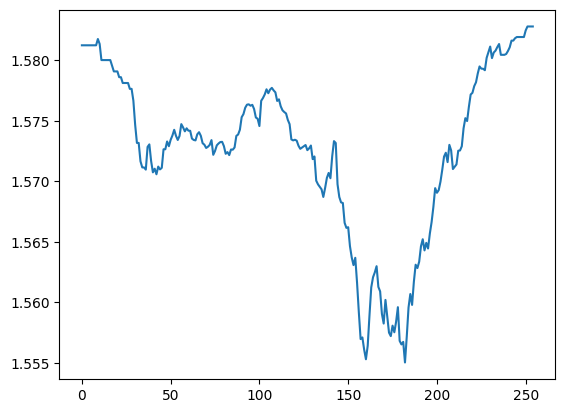

In [103]:
best, cond_entr = tree.single_feature_best_split(
    x_vec = test_x_vec,
    y_matrix = Y_,
    return_entropies = True
)
print(f"Best split: {best}")
plt.plot(cond_entr)
plt.show()

In [120]:
feature_to_use, boundary_to_use = tree.all_features_best_split(
    X = X_[:, :200],
    y_matrix = Y_
)
feature_to_use, boundary_to_use

(183, 94.5)